# Financial Transactions Anomaly Detection

This notebook covers the full workflow:
- Import libraries
- Create synthetic dataset with null and duplicate rows
- EDA before cleaning
- Data cleaning
- EDA after cleaning
- Basic plots
- Save cleaned data in `data` folder
- Feature selection
- Train/test split
- Train machine learning model
- Evaluate model
- Save model in `models` folder
- Reload model
- Predict using new transaction data


In [1]:
# 1. Import libraries
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


In [ ]:
# 2. Create project folders
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)

print('Folders created successfully!')

## 3. Create Synthetic Dataset

We are creating a beginner-friendly financial transactions dataset.  
It includes:
- normal transactions
- suspicious transactions
- null values
- duplicate rows


In [2]:
# 3. Create synthetic dataset
np.random.seed(42)

n = 5000

transaction_ids = np.arange(100001, 100001 + n)
customer_ids = np.random.randint(1000, 2000, n)

transaction_type = np.random.choice(
    ['payment', 'transfer', 'cash_out', 'cash_in', 'purchase'], n
)

device_type = np.random.choice(
    ['mobile', 'web', 'ATM', 'POS'], n
)

location = np.random.choice(
    ['Chennai', 'Bangalore', 'Mumbai', 'Delhi', 'Hyderabad'], n
)

merchant_category = np.random.choice(
    ['grocery', 'electronics', 'travel', 'fashion', 'utility'], n
)

hour_of_day = np.random.randint(0, 24, n)

# Create transaction amounts
transaction_amount = np.round(np.random.normal(loc=5000, scale=2500, size=n), 2)
transaction_amount = np.where(transaction_amount < 100, 100, transaction_amount)

# Create account balances
account_balance_before = np.round(np.random.normal(loc=50000, scale=15000, size=n), 2)
account_balance_before = np.where(account_balance_before < 1000, 1000, account_balance_before)

balance_after_transaction = account_balance_before - transaction_amount
balance_after_transaction = np.where(balance_after_transaction < 0, 0, balance_after_transaction)

transactions_last_24h = np.random.randint(1, 12, n)
is_international = np.random.choice([0, 1], n, p=[0.85, 0.15])

# Create anomaly label using business-like conditions
is_anomaly = (
    ((transaction_amount > 15000) & (transactions_last_24h > 8)) |
    ((hour_of_day >= 0) & (hour_of_day <= 4) & (transaction_amount > 12000)) |
    ((is_international == 1) & (transaction_amount > 10000)) |
    ((balance_after_transaction < 500) & (transaction_amount > 12000))
).astype(int)

df = pd.DataFrame({
    'transaction_id': transaction_ids,
    'customer_id': customer_ids,
    'transaction_type': transaction_type,
    'device_type': device_type,
    'location': location,
    'merchant_category': merchant_category,
    'hour_of_day': hour_of_day,
    'transaction_amount': transaction_amount,
    'account_balance_before': account_balance_before,
    'balance_after_transaction': balance_after_transaction,
    'transactions_last_24h': transactions_last_24h,
    'is_international': is_international,
    'is_anomaly': is_anomaly
})

print('Dataset created successfully!')
print('Shape:', df.shape)
df.head()

Dataset created successfully!
Shape: (5000, 13)


,transaction_id,customer_id,transaction_type,device_type,location,merchant_category,hour_of_day,transaction_amount,account_balance_before,balance_after_transaction,transactions_last_24h,is_international,is_anomaly
0,100001,1102,cash_out,POS,Chennai,fashion,23,4890.93,39330.34,34439.41,2,0,0
1,100002,1435,purchase,POS,Chennai,utility,9,7468.30,49501.33,42033.03,1,0,0
2,100003,1860,purchase,POS,Hyderabad,electronics,1,4215.65,68629.56,64413.91,9,0,0
3,100004,1270,payment,ATM,Hyderabad,electronics,5,2531.39,77627.34,75095.95,10,0,0
4,100005,1106,payment,mobile,Bangalore,electronics,2,4505.90,58896.07,54390.17,7,0,0


In [3]:
# 4. Add null values manually
df.loc[np.random.choice(df.index, 50, replace=False), 'device_type'] = np.nan
df.loc[np.random.choice(df.index, 50, replace=False), 'location'] = np.nan
df.loc[np.random.choice(df.index, 50, replace=False), 'transaction_amount'] = np.nan

# Add duplicate rows manually
duplicate_rows = df.sample(20, random_state=42)
df = pd.concat([df, duplicate_rows], ignore_index=True)

print('Null values and duplicate rows added successfully!')
print('Updated shape:', df.shape)

Null values and duplicate rows added successfully!
Updated shape: (5020, 13)


In [4]:
# 5. Save raw dataset
df.to_csv('data/raw_transactions.csv', index=False)
print('Raw dataset saved to data/raw_transactions.csv')

Raw dataset saved to data/raw_transactions.csv


## 4. EDA Before Cleaning

In [5]:
# View first few rows
df.head()

,transaction_id,customer_id,transaction_type,device_type,location,merchant_category,hour_of_day,transaction_amount,account_balance_before,balance_after_transaction,transactions_last_24h,is_international,is_anomaly
0,100001,1102,cash_out,POS,Chennai,fashion,23,4890.93,39330.34,34439.41,2,0,0
1,100002,1435,purchase,POS,Chennai,utility,9,7468.30,49501.33,42033.03,1,0,0
2,100003,1860,purchase,POS,Hyderabad,electronics,1,4215.65,68629.56,64413.91,9,0,0
3,100004,1270,payment,ATM,Hyderabad,electronics,5,2531.39,77627.34,75095.95,10,0,0
4,100005,1106,payment,mobile,Bangalore,electronics,2,4505.90,58896.07,54390.17,7,0,0


In [6]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5020 entries, 0 to 5019
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             5020 non-null   int64  
 1   customer_id                5020 non-null   int64  
 2   transaction_type           5020 non-null   object 
 3   device_type                4970 non-null   object 
 4   location                   4970 non-null   object 
 5   merchant_category          5020 non-null   object 
 6   hour_of_day                5020 non-null   int64  
 7   transaction_amount         4970 non-null   float64
 8   account_balance_before     5020 non-null   float64
 9   balance_after_transaction  5020 non-null   float64
 10  transactions_last_24h      5020 non-null   int64  
 11  is_international           5020 non-null   int64  
 12  is_anomaly                 5020 non-null   int64  
dtypes: float64(3), int64(6), object(4)
memory usage:

In [7]:
# Check missing values
df.isnull().sum()

transaction_id                0
customer_id                   0
transaction_type              0
device_type                  50
location                     50
merchant_category             0
hour_of_day                   0
transaction_amount           50
account_balance_before        0
balance_after_transaction     0
transactions_last_24h         0
is_international              0
is_anomaly                    0
dtype: int64

In [8]:
# Check duplicate rows
df.duplicated().sum()

np.int64(20)

In [9]:
# Statistical summary
df.describe(include='all')

,transaction_id,customer_id,transaction_type,device_type,location,merchant_category,hour_of_day,transaction_amount,account_balance_before,balance_after_transaction,transactions_last_24h,is_international,is_anomaly
count,5020.000000,5020.000000,5020,4970,4970,5020,5020.000000,4970.000000,5020.000000,5020.000000,5020.000000,5020.000000,5020.000000
unique,NaN,NaN,5,4,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,transfer,mobile,Bangalore,electronics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1043,1297,1020,1060,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,102497.293426,1505.990438,NaN,NaN,NaN,NaN,11.532271,5088.948213,50018.497685,44936.320747,6.043227,0.153187,0.004183
std,1442.973335,290.842221,NaN,NaN,NaN,NaN,6.904434,2457.121688,14963.081699,15131.353944,3.154001,0.360204,0.064549
min,100001.000000,1000.000000,NaN,NaN,NaN,NaN,0.000000,100.000000,1000.000000,0.000000,1.000000,0.000000,0.000000
25%,101246.750000,1253.000000,NaN,NaN,NaN,NaN,6.000000,3370.380000,39655.805000,34444.887500,3.000000,0.000000,0.000000
50%,102495.500000,1510.000000,NaN,NaN,NaN,NaN,12.000000,5033.155000,49965.590000,44903.950000,6.000000,0.000000,0.000000
75%,103745.250000,1761.000000,NaN,NaN,NaN,NaN,17.000000,6752.930000,60046.465000,55242.682500,9.000000,0.000000,0.000000


In [10]:
# Class distribution
df['is_anomaly'].value_counts()

is_anomaly
0    4999
1      21
Name: count, dtype: int64

## 5. Basic Plots Before Cleaning

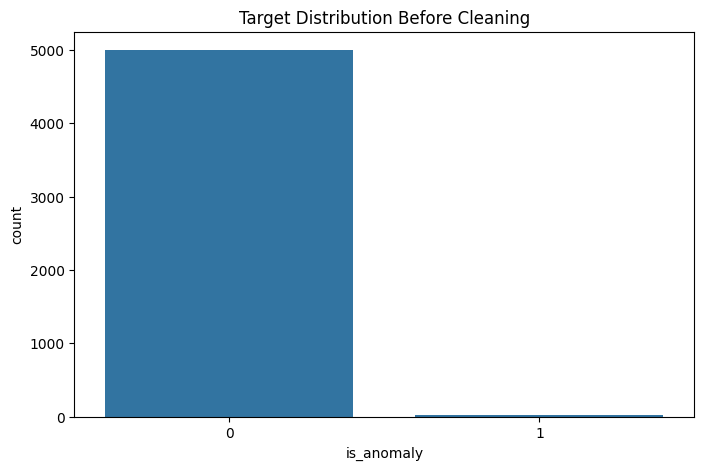

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(x='is_anomaly', data=df)
plt.title('Target Distribution Before Cleaning')
plt.show()

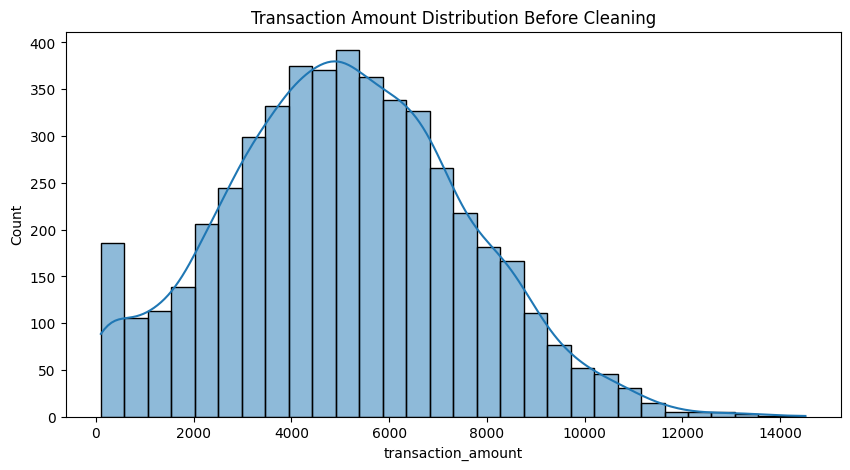

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df['transaction_amount'], bins=30, kde=True)
plt.title('Transaction Amount Distribution Before Cleaning')
plt.show()

## 6. Data Cleaning

In [13]:
# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing categorical values using mode
df['device_type'].fillna(df['device_type'].mode()[0], inplace=True)
df['location'].fillna(df['location'].mode()[0], inplace=True)

# Fill missing numerical values using median
df['transaction_amount'].fillna(df['transaction_amount'].median(), inplace=True)

print('Data cleaning completed successfully!')

Data cleaning completed successfully!


In [14]:
# Verify after cleaning
print('Missing values after cleaning:')
print(df.isnull().sum())

print('\nDuplicate rows after cleaning:', df.duplicated().sum())

Missing values after cleaning:
transaction_id               0
customer_id                  0
transaction_type             0
device_type                  0
location                     0
merchant_category            0
hour_of_day                  0
transaction_amount           0
account_balance_before       0
balance_after_transaction    0
transactions_last_24h        0
is_international             0
is_anomaly                   0
dtype: int64

Duplicate rows after cleaning: 0


In [15]:
# Save cleaned dataset
df.to_csv('data/cleaned_transactions.csv', index=False)
print('Cleaned dataset saved to data/cleaned_transactions.csv')

Cleaned dataset saved to data/cleaned_transactions.csv


## 7. EDA After Cleaning

In [16]:
df.head()

,transaction_id,customer_id,transaction_type,device_type,location,merchant_category,hour_of_day,transaction_amount,account_balance_before,balance_after_transaction,transactions_last_24h,is_international,is_anomaly
0,100001,1102,cash_out,POS,Chennai,fashion,23,4890.93,39330.34,34439.41,2,0,0
1,100002,1435,purchase,POS,Chennai,utility,9,7468.30,49501.33,42033.03,1,0,0
2,100003,1860,purchase,POS,Hyderabad,electronics,1,4215.65,68629.56,64413.91,9,0,0
3,100004,1270,payment,ATM,Hyderabad,electronics,5,2531.39,77627.34,75095.95,10,0,0
4,100005,1106,payment,mobile,Bangalore,electronics,2,4505.90,58896.07,54390.17,7,0,0


In [17]:
df.shape

(5000, 13)

## 8. Basic Plots After Cleaning

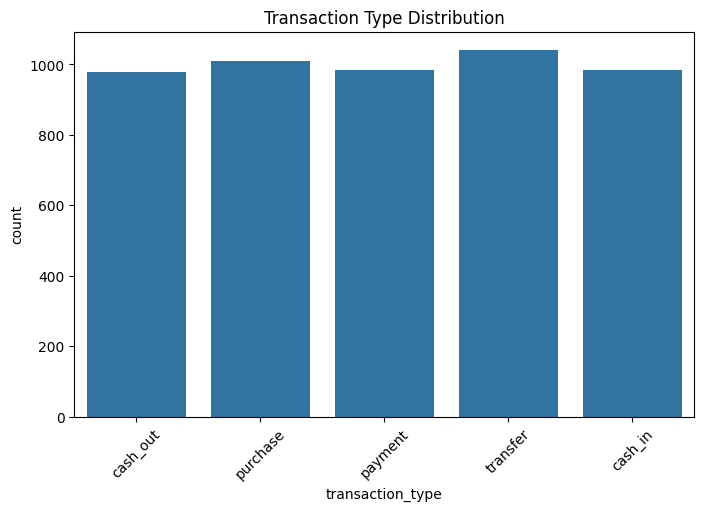

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(x='transaction_type', data=df)
plt.title('Transaction Type Distribution')
plt.xticks(rotation=45)
plt.show()

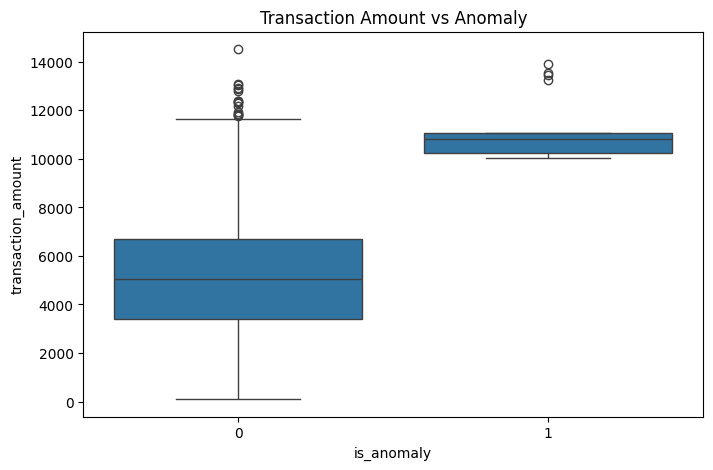

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_anomaly', y='transaction_amount', data=df)
plt.title('Transaction Amount vs Anomaly')
plt.show()

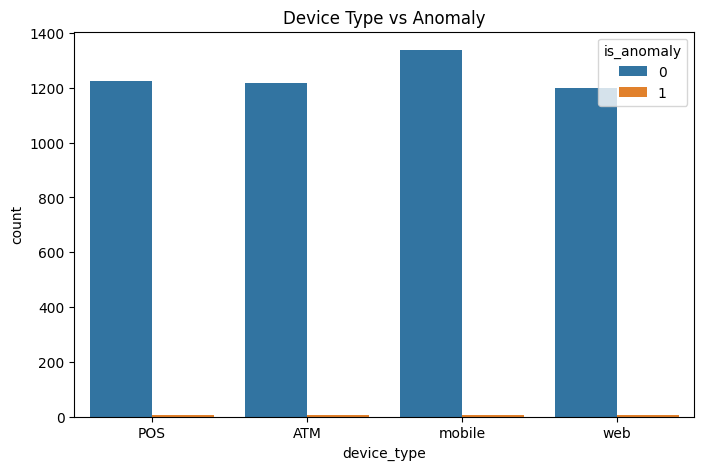

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(x='device_type', hue='is_anomaly', data=df)
plt.title('Device Type vs Anomaly')
plt.show()

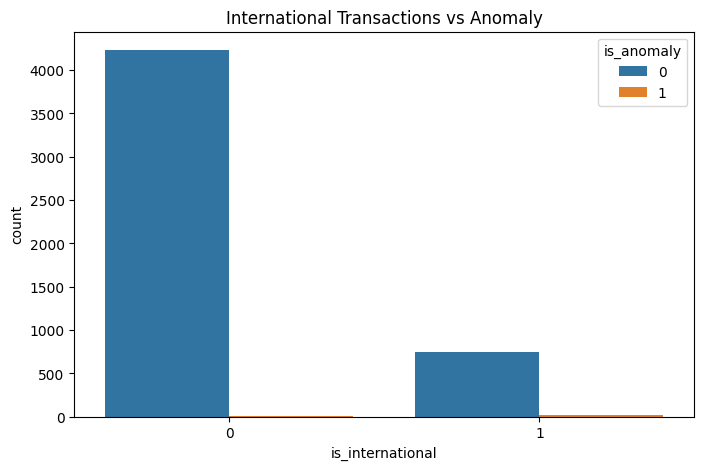

In [21]:
plt.figure(figsize=(8, 5))
sns.countplot(x='is_international', hue='is_anomaly', data=df)
plt.title('International Transactions vs Anomaly')
plt.show()

## 9. Encode Categorical Columns

In [22]:
label_encoders = {}
categorical_cols = ['transaction_type', 'device_type', 'location', 'merchant_category']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

joblib.dump(label_encoders, 'models/label_encoders.pkl')
print('Categorical columns encoded and encoders saved successfully!')
df.head()

Categorical columns encoded and encoders saved successfully!


,transaction_id,customer_id,transaction_type,device_type,location,merchant_category,hour_of_day,transaction_amount,account_balance_before,balance_after_transaction,transactions_last_24h,is_international,is_anomaly
0,100001,1102,1,1,1,1,23,4890.93,39330.34,34439.41,2,0,0
1,100002,1435,3,1,1,4,9,7468.30,49501.33,42033.03,1,0,0
2,100003,1860,3,1,3,0,1,4215.65,68629.56,64413.91,9,0,0
3,100004,1270,2,0,3,0,5,2531.39,77627.34,75095.95,10,0,0
4,100005,1106,2,2,0,0,2,4505.90,58896.07,54390.17,7,0,0


## 10. Correlation and Feature Selection

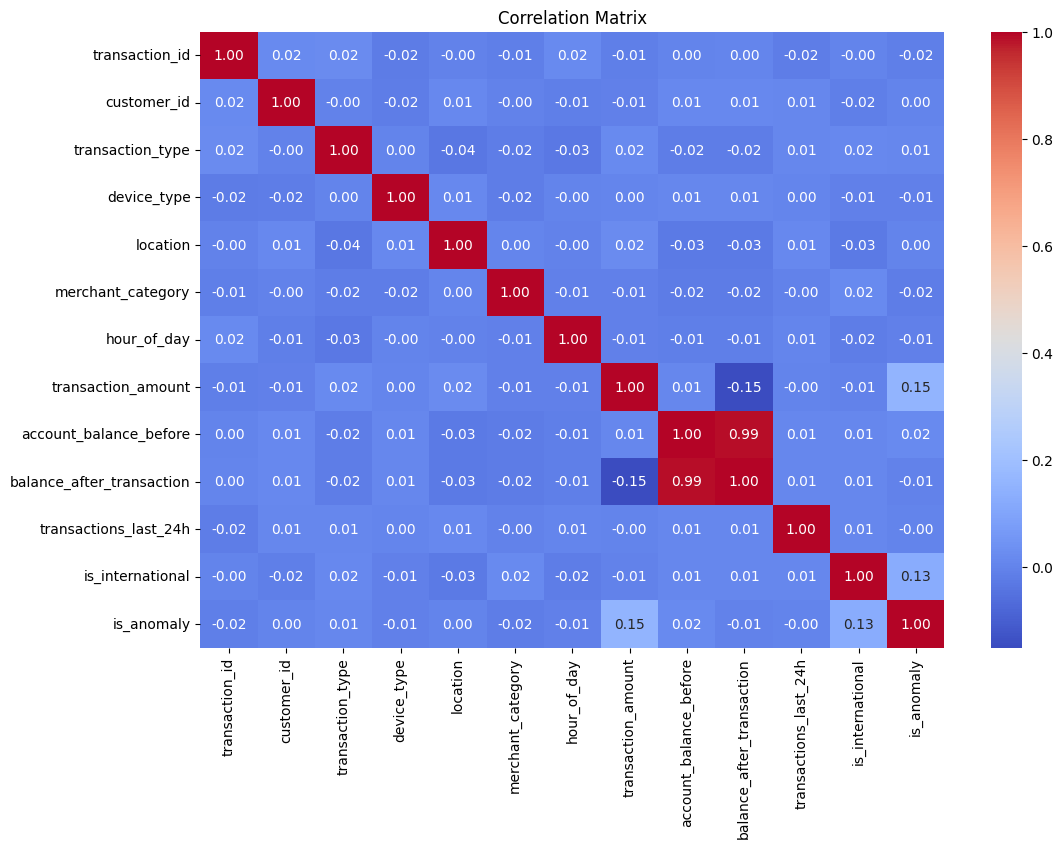

In [23]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [24]:
# Select useful features based on correlation and domain understanding
selected_features = [
    'transaction_type',
    'device_type',
    'location',
    'merchant_category',
    'hour_of_day',
    'transaction_amount',
    'account_balance_before',
    'balance_after_transaction',
    'transactions_last_24h',
    'is_international'
]

X = df[selected_features]
y = df['is_anomaly']

print('Selected features:')
print(selected_features)

Selected features:
['transaction_type', 'device_type', 'location', 'merchant_category', 'hour_of_day', 'transaction_amount', 'account_balance_before', 'balance_after_transaction', 'transactions_last_24h', 'is_international']


## 11. Train-Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (4000, 10)
X_test shape: (1000, 10)
y_train shape: (4000,)
y_test shape: (1000,)


## 12. Feature Scaling

In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, 'models/scaler.pkl')
print('Scaler saved successfully!')

Scaler saved successfully!


## 13. Train Machine Learning Model

**Chosen algorithm: Random Forest Classifier**  
Reason:
- works well for binary classification
- handles nonlinear relationships
- easy to understand
- gives feature importance
- suitable for beginner projects


In [27]:
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)
print('Model trained successfully!')

Model trained successfully!


## 14. Model Evaluation

In [28]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', round(accuracy, 4))

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       996
           1       1.00      1.00      1.00         4

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Confusion Matrix:
[[996   0]
 [  0   4]]


## 15. Feature Importance

In [29]:
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
5,transaction_amount,0.568060
9,is_international,0.214202
6,account_balance_before,0.054958
7,balance_after_transaction,0.047424
4,hour_of_day,0.038971
8,transactions_last_24h,0.029848
0,transaction_type,0.017568
2,location,0.011332
3,merchant_category,0.010372
1,device_type,0.007264


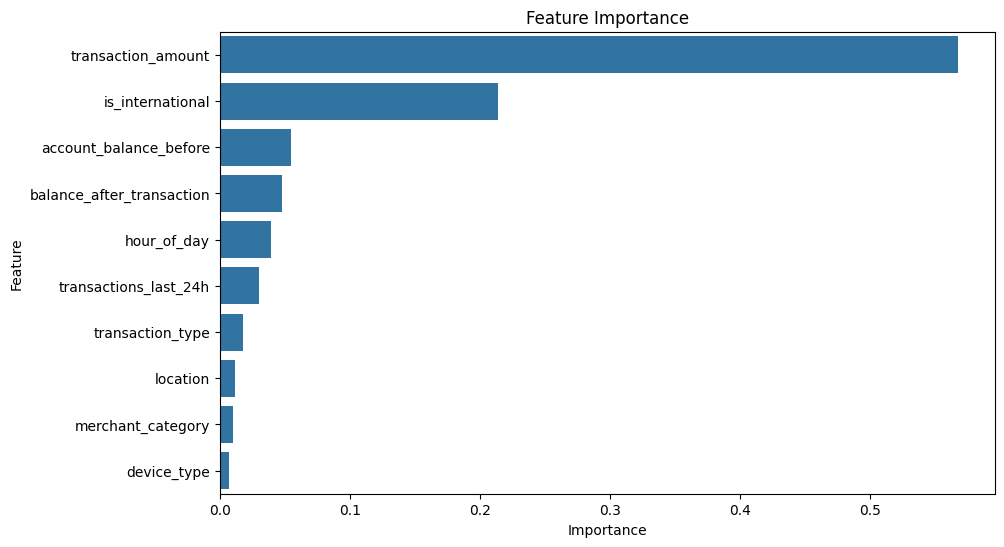

In [30]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()

## 16. Save Model

In [31]:
joblib.dump(model, 'models/anomaly_model.pkl')
print('Model saved successfully in models/anomaly_model.pkl')

Model saved successfully in models/anomaly_model.pkl


## 17. Reload Model

In [32]:
loaded_model = joblib.load('models/anomaly_model.pkl')
loaded_scaler = joblib.load('models/scaler.pkl')
loaded_encoders = joblib.load('models/label_encoders.pkl')

print('Model, scaler, and encoders reloaded successfully!')

Model, scaler, and encoders reloaded successfully!


## 18. Prediction with New Dataset

In [33]:
# Create new transaction data for testing prediction
new_data = pd.DataFrame({
    'transaction_type': [loaded_encoders['transaction_type'].transform(['transfer'])[0]],
    'device_type': [loaded_encoders['device_type'].transform(['mobile'])[0]],
    'location': [loaded_encoders['location'].transform(['Mumbai'])[0]],
    'merchant_category': [loaded_encoders['merchant_category'].transform(['electronics'])[0]],
    'hour_of_day': [2],
    'transaction_amount': [18000],
    'account_balance_before': [25000],
    'balance_after_transaction': [7000],
    'transactions_last_24h': [10],
    'is_international': [1]
})

new_data

,transaction_type,device_type,location,merchant_category,hour_of_day,transaction_amount,account_balance_before,balance_after_transaction,transactions_last_24h,is_international
0,4,2,4,0,2,18000,25000,7000,10,1


In [34]:
# Scale the new input data
new_data_scaled = loaded_scaler.transform(new_data)

# Predict
prediction = loaded_model.predict(new_data_scaled)
prediction_proba = loaded_model.predict_proba(new_data_scaled)

print('Prediction:', prediction[0])
print('0 = Normal Transaction, 1 = Anomaly Transaction')
print('Prediction Probability:', prediction_proba)

Prediction: 0
0 = Normal Transaction, 1 = Anomaly Transaction
Prediction Probability: [[0.52666667 0.47333333]]


## 19. Final Conclusion

In this notebook, we:
- created a synthetic financial transaction dataset
- added null and duplicate values
- performed EDA before and after cleaning
- cleaned the data
- selected important features
- trained a Random Forest model
- evaluated the model
- saved and reloaded the model
- predicted anomaly for a new transaction
